<a href="https://colab.research.google.com/github/syakilameilanaruslin-sys/machine-learning-final-uts/blob/main/machine_learning_finallll.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data_baru.csv to data_baru.csv


#data understanding

In [ ]:
df = pd.read_csv('data_baru.csv', sep=';')
display(df.head())

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
0,1,0.370594,0.424389,0.405750,0.601457,0.601457,0.998969,0.796887,0.808809,0.302646,...,0.716845,0.009219,0.622879,0.601453,0.827890,0.290202,0.026601,0.564050,1,0.016469
1,1,0.464291,0.538214,0.516730,0.610235,0.610235,0.998946,0.797380,0.809301,0.303556,...,0.795297,0.008323,0.623652,0.610237,0.839969,0.283846,0.264577,0.570175,1,0.020794
2,1,0.426071,0.499019,0.472295,0.601450,0.601364,0.998857,0.796403,0.808388,0.302035,...,0.774670,0.040003,0.623841,0.601449,0.836774,0.290189,0.026555,0.563706,1,0.016474
3,1,0.399844,0.451265,0.457733,0.583541,0.583541,0.998700,0.796967,0.808966,0.303350,...,0.739555,0.003252,0.622929,0.583538,0.834697,0.281721,0.026697,0.564663,1,0.023982
4,1,0.465022,0.538432,0.522298,0.598783,0.598783,0.998973,0.797366,0.809304,0.303475,...,0.795016,0.003878,0.623521,0.598782,0.839973,0.278514,0.024752,0.575617,1,0.035490


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6819 entries, 0 to 6818
Data columns (total 96 columns):
 #   Column                                                    Non-Null Count  Dtype  
---  ------                                                    --------------  -----  
 0   Bankrupt?                                                 6819 non-null   int64  
 1    ROA(C) before interest and depreciation before interest  6819 non-null   float64
 2    ROA(A) before interest and % after tax                   6819 non-null   float64
 3    ROA(B) before interest and depreciation after tax        6819 non-null   float64
 4    Operating Gross Margin                                   6819 non-null   float64
 5    Realized Sales Gross Margin                              6819 non-null   float64
 6    Operating Profit Rate                                    6819 non-null   float64
 7    Pre-tax net Interest Rate                                6819 non-null   float64
 8    After-tax net Int

In [ ]:
display(df.describe())

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,...,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,...,0.807760,1.862942e+07,0.623915,0.607946,0.840402,0.280365,0.027541,0.565358,1.0,0.047578
std,0.176710,0.060686,0.065620,0.061595,0.016934,0.016916,0.013010,0.012869,0.013601,0.011163,...,0.040332,3.764501e+08,0.012290,0.016934,0.014523,0.014463,0.015668,0.013214,0.0,0.050014
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,0.000000,0.476527,0.535543,0.527277,0.600445,0.600434,0.998969,0.797386,0.809312,0.303466,...,0.796750,9.036205e-04,0.623636,0.600443,0.840115,0.276944,0.026791,0.565158,1.0,0.024477
50%,0.000000,0.502706,0.559802,0.552278,0.605997,0.605976,0.999022,0.797464,0.809375,0.303525,...,0.810619,2.085213e-03,0.623879,0.605998,0.841179,0.278778,0.026808,0.565252,1.0,0.033798
75%,0.000000,0.535563,0.589157,0.584105,0.613914,0.613842,0.999095,0.797579,0.809469,0.303585,...,0.826455,5.269777e-03,0.624168,0.613913,0.842357,0.281449,0.026913,0.565725,1.0,0.052838
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000


# Data Preprocessing

In [ ]:
print("Missing values:", df.isnull().sum().sum())

Missing values: 0


In [ ]:
print("\nStatistik ROA(A):")
print(df[' ROA(A) before interest and % after tax'].describe())


Statistik ROA(A):
count    6819.000000
mean        0.558625
std         0.065620
min         0.000000
25%         0.535543
50%         0.559802
75%         0.589157
max         1.000000
Name:  ROA(A) before interest and % after tax, dtype: float64


In [ ]:
# Buat 3 kelas
roa_col = ' ROA(A) before interest and % after tax'
median_roa = df[df['Bankrupt?'] == 0][roa_col].median()
print(f"Median ROA perusahaan tidak bangkrut: {median_roa}")

def categorize(row):
    if row['Bankrupt?'] == 1:
        return 2  # Distress/Bangkrut
    elif row[roa_col] >= median_roa:
        return 0  # Sehat
    else:
        return 1  # Rawan

df['Risk_Class'] = df.apply(categorize, axis=1)

print("\nDistribusi kelas:")
print(df['Risk_Class'].value_counts())
print("\nKeterangan:")
print("0 = Sehat, 1 = Rawan, 2 = Bangkrut")

Median ROA perusahaan tidak bangkrut: 0.561218927169647

Distribusi kelas:
Risk_Class
0    3302
1    3297
2     220
Name: count, dtype: int64

Keterangan:
0 = Sehat, 1 = Rawan, 2 = Bangkrut


In [ ]:
from imblearn.over_sampling import SMOTE

X = df.drop(columns=['Bankrupt?', 'Risk_Class'])
y = df['Risk_Class']

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

print("Distribusi setelah SMOTE:")
print(pd.Series(y_res).value_counts())

Distribusi setelah SMOTE:
Risk_Class
2    3302
1    3302
0    3302
Name: count, dtype: int64


# EDA

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

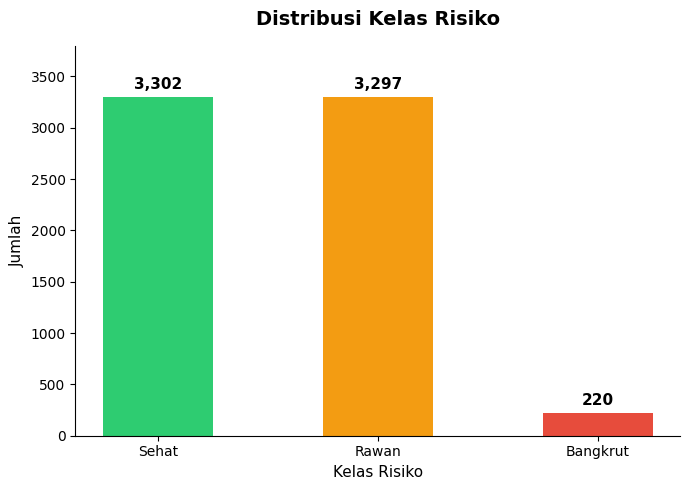

In [ ]:
labels = ['Sehat', 'Rawan', 'Bangkrut']
counts = df['Risk_Class'].value_counts().sort_index()
colors = ['#2ecc71', '#f39c12', '#e74c3c']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, counts, color=colors, width=0.5, edgecolor='none')

# Tambah angka di atas bar
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{count:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Distribusi Kelas Risiko', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Kelas Risiko', fontsize=11)
ax.set_ylabel('Jumlah', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, max(counts) * 1.15)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


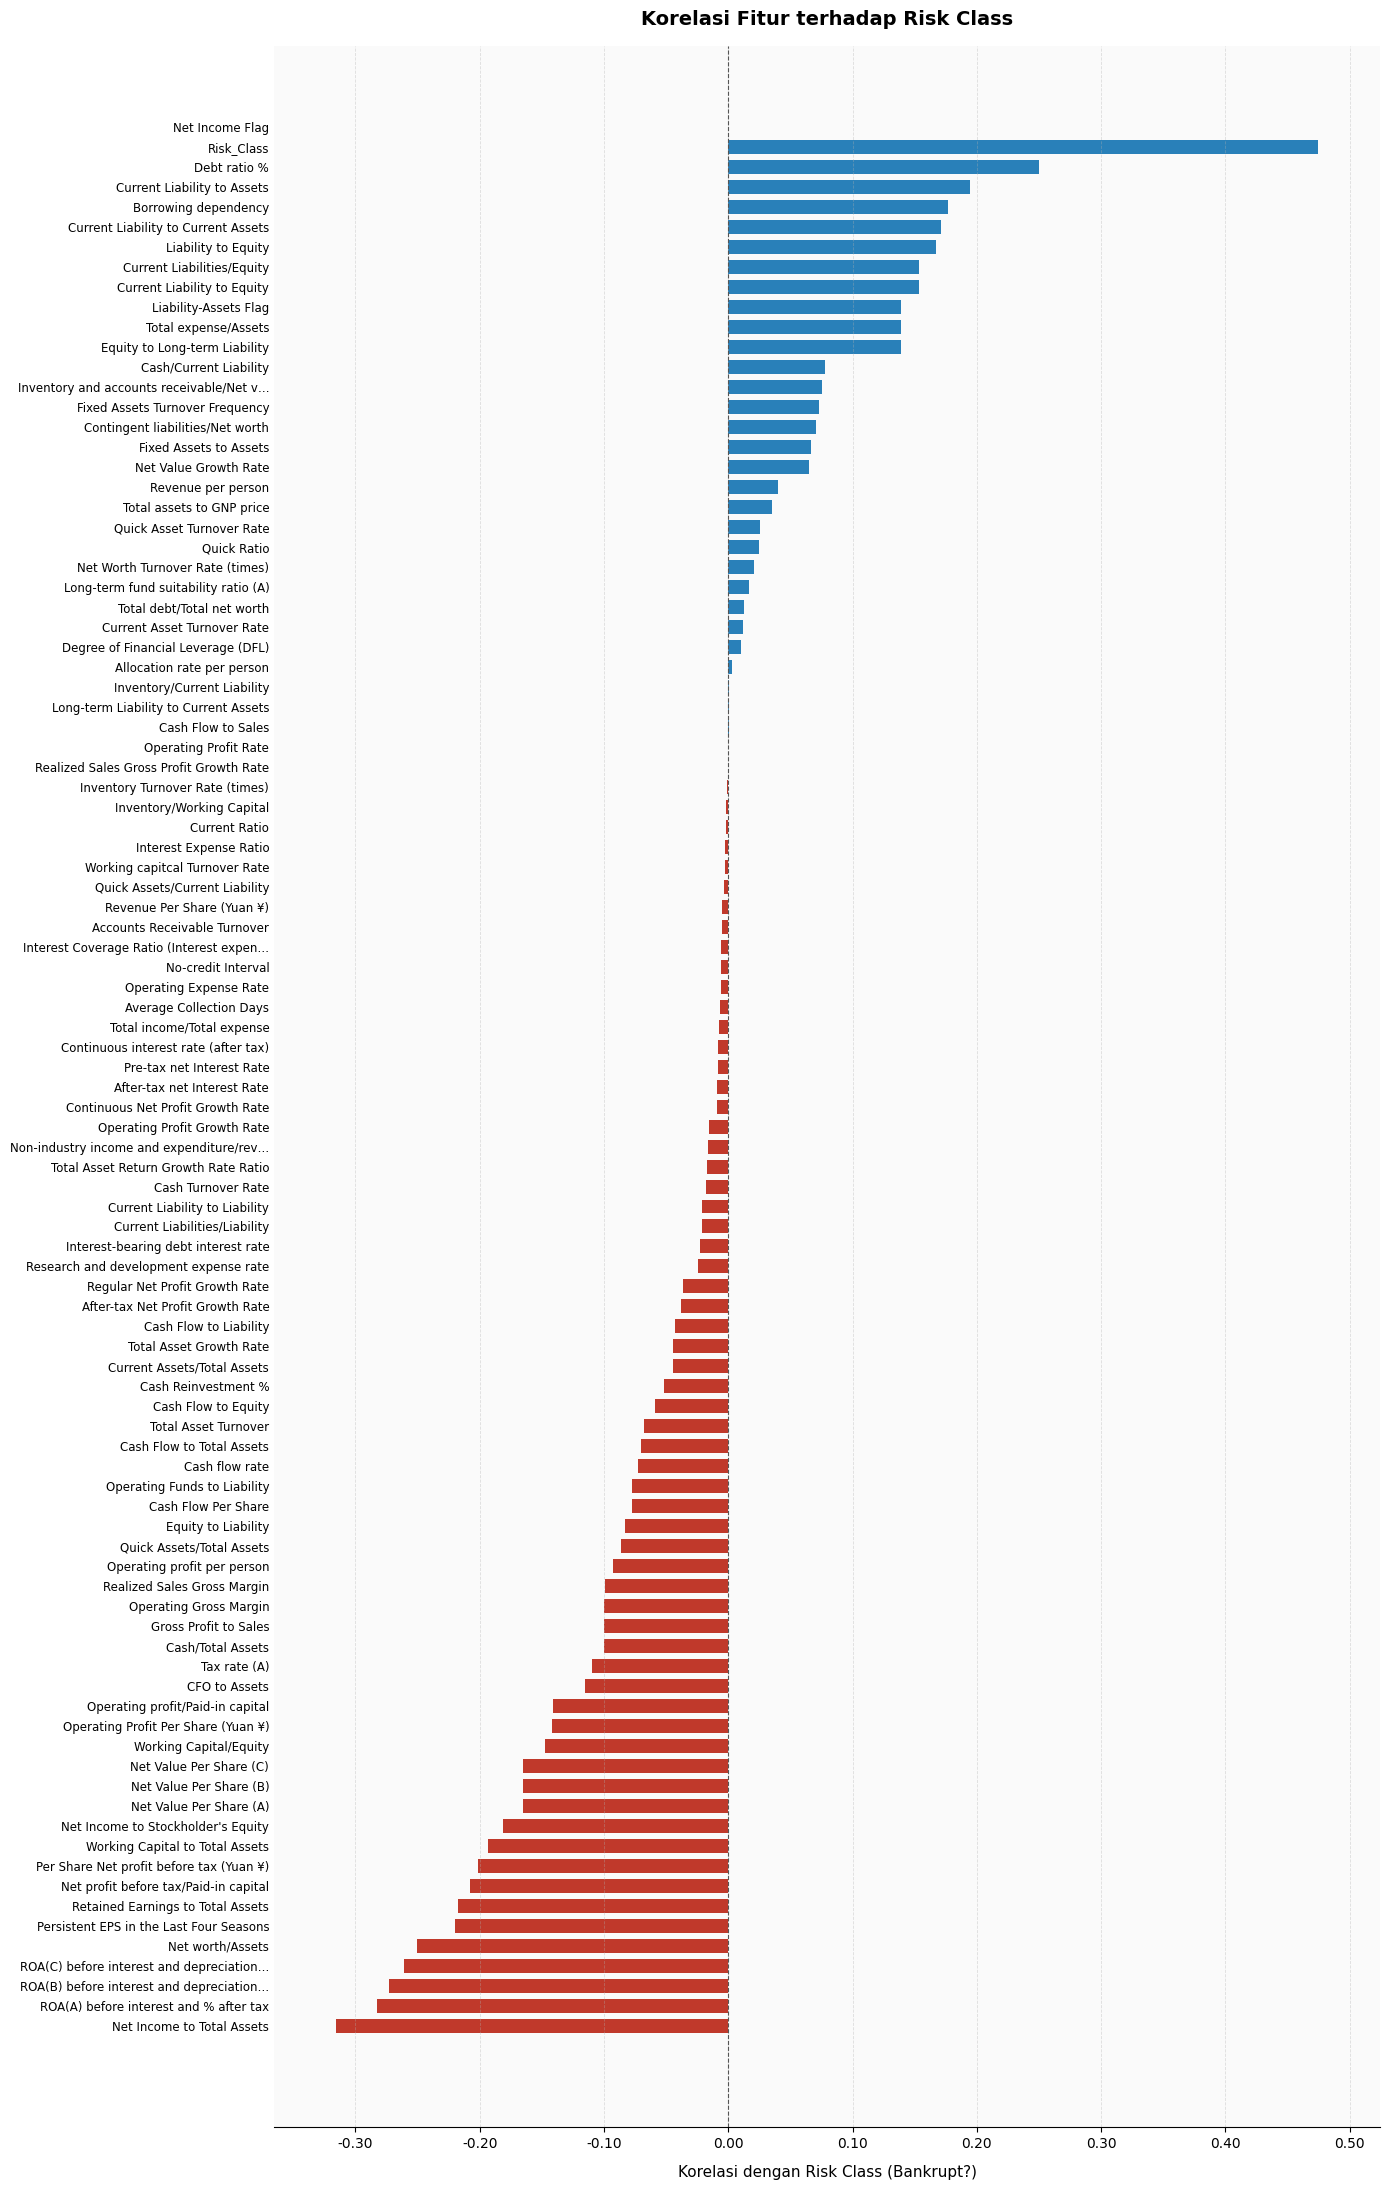

In [ ]:
import numpy as np
import matplotlib.ticker as ticker

df.columns = df.columns.str.strip()

target = 'Bankrupt?'
features = [c for c in df.columns if c != target]

corr = df[features].corrwith(df[target]).sort_values()

def shorten(label, max_len=40):
    return label if len(label) <= max_len else label[:max_len-1] + '…'

labels = [shorten(f) for f in corr.index]
values = corr.values
colors = ['#c0392b' if v < 0 else '#2980b9' for v in values]

fig, ax = plt.subplots(figsize=(14, 22))
y = np.arange(len(values))
ax.barh(y, values, color=colors, height=0.7, edgecolor='none')

ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=8.5)
ax.axvline(0, color='#555555', linewidth=0.8, linestyle='--')
ax.set_xlabel('Korelasi dengan Risk Class (Bankrupt?)', fontsize=11, labelpad=10)
ax.set_title('Korelasi Fitur terhadap Risk Class', fontsize=14, fontweight='bold', pad=15)
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax.set_xlim(min(values) - 0.05, max(values) + 0.05)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.tick_params(axis='y', length=0)
ax.grid(axis='x', linestyle='--', alpha=0.4, linewidth=0.6)
ax.set_facecolor('#fafafa')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.savefig('korelasi_fitur_risk_class.png', dpi=150, bbox_inches='tight')
plt.show()

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


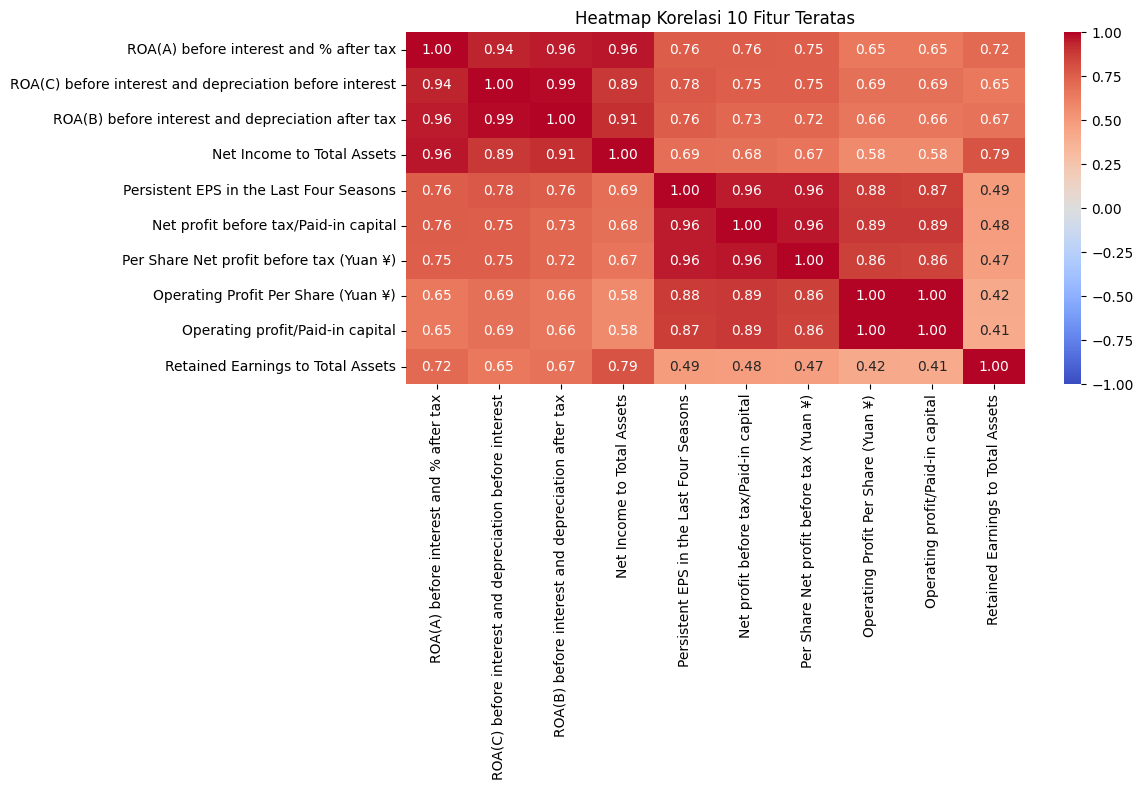

In [ ]:
# Korelasi fitur terhadap target tanpa Risk_Class

# Recreate Risk_Class column as df was overwritten in a previous cell
roa_col = 'ROA(A) before interest and % after tax'
median_roa = df[df['Bankrupt?'] == 0][roa_col].median()

def categorize(row):
    if row['Bankrupt?'] == 1:
        return 2  # Distress/Bangkrut
    elif row[roa_col] >= median_roa:
        return 0  # Sehat
    else:
        return 1  # Rawan

df['Risk_Class'] = df.apply(categorize, axis=1)

corr = df.drop(columns=['Bankrupt?', 'Risk_Class']).corrwith(df['Risk_Class']).sort_values()

# Ambil 10 fitur terkorelasi tertinggi (tanpa Risk_Class)
top_features = corr.abs().nlargest(10).index.tolist()

plt.figure(figsize=(12,8))
sns.heatmap(df[top_features].corr(),
            annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1)
plt.title('Heatmap Korelasi 10 Fitur Teratas')
plt.tight_layout()
plt.show()

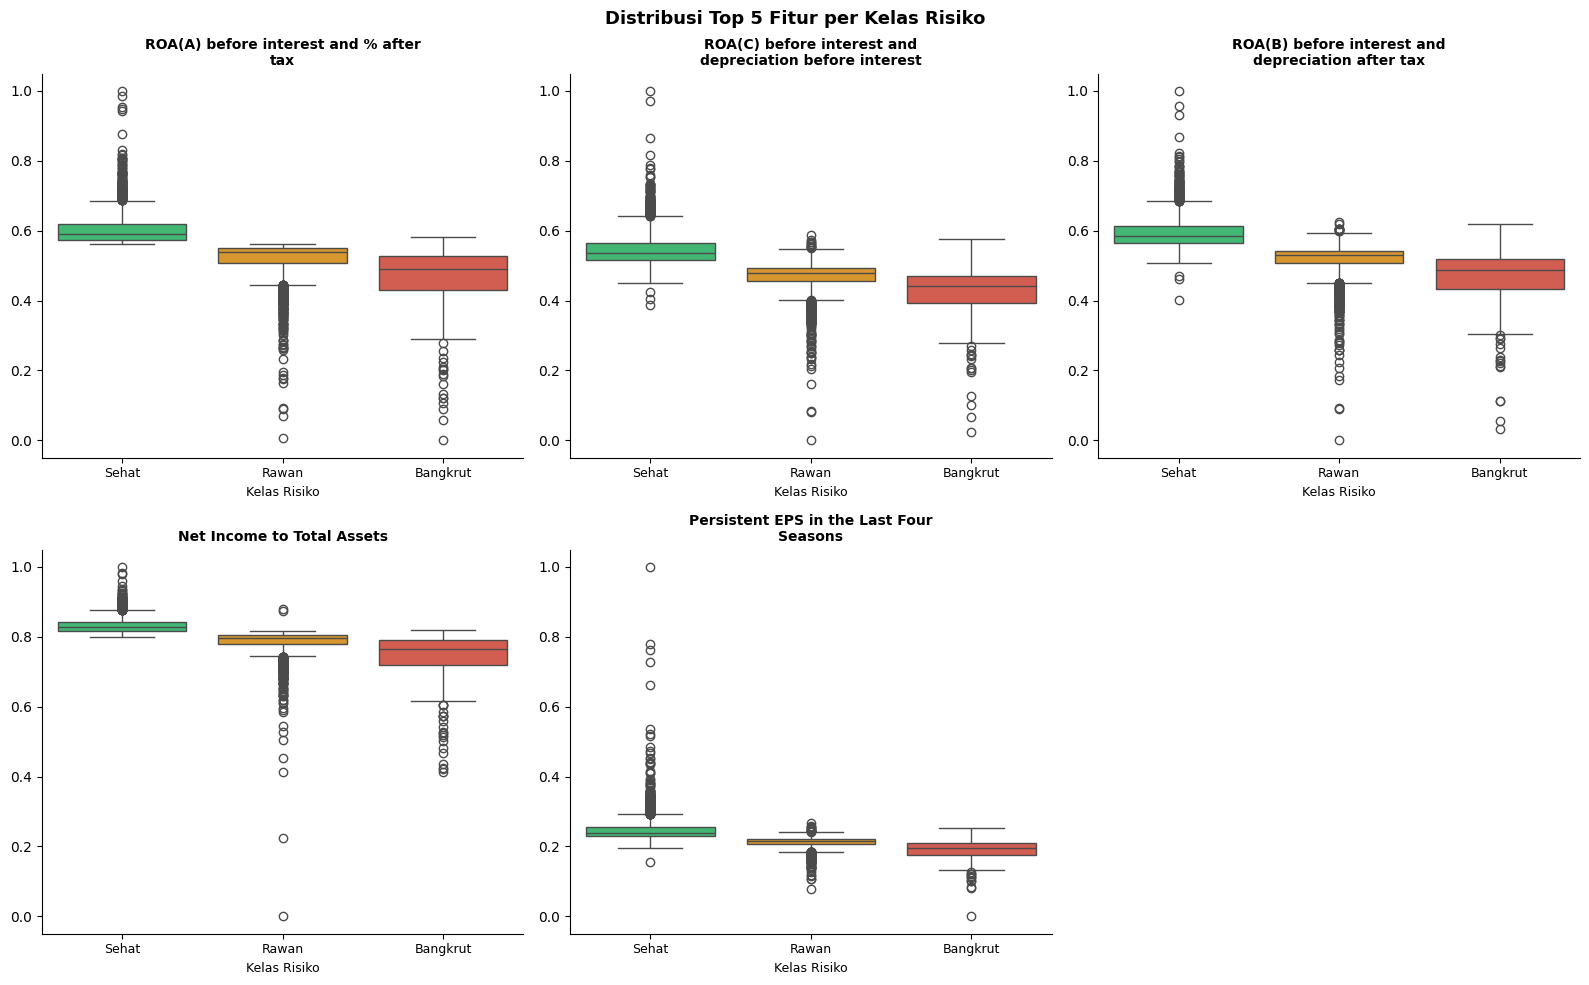

In [ ]:
top5 = corr.abs().nlargest(5).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(top5):
    ax = axes[i]
    sns.boxplot(
        x='Risk_Class', y=col, data=df,
        hue='Risk_Class', palette={0: '#2ecc71', 1: '#f39c12', 2: '#e74c3c'},
        legend=False, ax=ax
    )
    # Wrap judul panjang ke 2 baris
    import textwrap
    short_title = '\n'.join(textwrap.wrap(col, width=35))
    ax.set_title(short_title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Kelas Risiko', fontsize=9)
    ax.set_ylabel('')
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['Sehat', 'Rawan', 'Bangkrut'], fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Sembunyikan subplot ke-6 yang kosong
axes[5].set_visible(False)

plt.suptitle('Distribusi Top 5 Fitur per Kelas Risiko', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Data splitting

In [ ]:
# Variasi 1: 80:20
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42)

# Variasi 2: 70:30
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_res, y_res, test_size=0.3, random_state=42)

# Variasi 3: 90:10
X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X_res, y_res, test_size=0.1, random_state=42)

for i, (tr, te) in enumerate([(X_train1,X_test1),
                               (X_train2,X_test2),
                               (X_train3,X_test3)], 1):
    total = tr.shape[0] + te.shape[0]
    print(f"Variasi {i} → Train: {tr.shape[0]} | Test: {te.shape[0]}")

Variasi 1 → Train: 7924 | Test: 1982
Variasi 2 → Train: 6934 | Test: 2972
Variasi 3 → Train: 8915 | Test: 991


# model building

Random Forest

In [ ]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train1, y_train1)
acc1 = accuracy_score(y_test1, rf.predict(X_test1))

rf.fit(X_train2, y_train2)
acc2 = accuracy_score(y_test2, rf.predict(X_test2))

rf.fit(X_train3, y_train3)
acc3 = accuracy_score(y_test3, rf.predict(X_test3))

print("\n=== Akurasi Random Forest (Default) ===")
print(f"Variasi 1 (80:20): {acc1*100:.2f}%")
print(f"Variasi 2 (70:30): {acc2*100:.2f}%")
print(f"Variasi 3 (90:10): {acc3*100:.2f}%")


=== Akurasi Random Forest (Default) ===
Variasi 1 (80:20): 97.33%
Variasi 2 (70:30): 97.54%
Variasi 3 (90:10): 97.98%


XGBoost

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42, eval_metric='mlogloss')

xgb.fit(X_train1, y_train1)
acc1 = accuracy_score(y_test1, xgb.predict(X_test1))

xgb.fit(X_train2, y_train2)
acc2 = accuracy_score(y_test2, xgb.predict(X_test2))

xgb.fit(X_train3, y_train3)
acc3 = accuracy_score(y_test3, xgb.predict(X_test3))

print("=== Akurasi XGBoost (Default) ===")
print(f"Variasi 1 (80:20): {acc1*100:.2f}%")
print(f"Variasi 2 (70:30): {acc2*100:.2f}%")
print(f"Variasi 3 (90:10): {acc3*100:.2f}%")

=== Akurasi XGBoost (Default) ===
Variasi 1 (80:20): 98.44%
Variasi 2 (70:30): 98.38%
Variasi 3 (90:10): 98.69%


Decission Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train1, y_train1)
acc1 = accuracy_score(y_test1, dt.predict(X_test1))

dt.fit(X_train2, y_train2)
acc2 = accuracy_score(y_test2, dt.predict(X_test2))

dt.fit(X_train3, y_train3)
acc3 = accuracy_score(y_test3, dt.predict(X_test3))

print("=== Akurasi Decision Tree (Default) ===")
print(f"Variasi 1 (80:20): {acc1*100:.2f}%")
print(f"Variasi 2 (70:30): {acc2*100:.2f}%")
print(f"Variasi 3 (90:10): {acc3*100:.2f}%")

=== Akurasi Decision Tree (Default) ===
Variasi 1 (80:20): 94.15%
Variasi 2 (70:30): 94.18%
Variasi 3 (90:10): 94.65%


# Hyperparameter tuning

tuning random forest

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Gunakan variasi terbaik (Variasi 3: 90:10)
random_search.fit(X_train3, y_train3)

print("Parameter terbaik:", random_search.best_params_)
print(f"Akurasi CV: {random_search.best_score_*100:.2f}%")

y_pred_tuned = random_search.best_estimator_.predict(X_test3)
print(f"Akurasi test set: {accuracy_score(y_test3, y_pred_tuned)*100:.2f}%")

print("\n=== Classification Report ===")
print(classification_report(y_test3, y_pred_tuned,
      target_names=['Sehat','Rawan','Bangkrut']))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Parameter terbaik: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
Akurasi CV: 96.76%
Akurasi test set: 97.88%

=== Classification Report ===
              precision    recall  f1-score   support

       Sehat       1.00      0.99      1.00       324
       Rawan       0.98      0.95      0.97       329
    Bangkrut       0.96      0.99      0.97       338

    accuracy                           0.98       991
   macro avg       0.98      0.98      0.98       991
weighted avg       0.98      0.98      0.98       991



tuning XGBoost

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

random_search_xgb = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='mlogloss'),
    param_grid_xgb,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search_xgb.fit(X_train3, y_train3)

print("Parameter terbaik:", random_search_xgb.best_params_)
print(f"Akurasi CV: {random_search_xgb.best_score_*100:.2f}%")

y_pred_xgb_tuned = random_search_xgb.best_estimator_.predict(X_test3)
print(f"Akurasi test set: {accuracy_score(y_test3, y_pred_xgb_tuned)*100:.2f}%")

print("\n=== Classification Report ===")
print(classification_report(y_test3, y_pred_xgb_tuned,
      target_names=['Sehat','Rawan','Bangkrut']))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Parameter terbaik: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.3, 'colsample_bytree': 0.8}
Akurasi CV: 98.16%
Akurasi test set: 98.59%

=== Classification Report ===
              precision    recall  f1-score   support

       Sehat       0.99      1.00      0.99       324
       Rawan       0.99      0.97      0.98       329
    Bangkrut       0.98      0.99      0.99       338

    accuracy                           0.99       991
   macro avg       0.99      0.99      0.99       991
weighted avg       0.99      0.99      0.99       991



tuning decission tree

In [ ]:
param_grid_dt = {
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

random_search_dt = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search_dt.fit(X_train3, y_train3)

print("Parameter terbaik:", random_search_dt.best_params_)
print(f"Akurasi CV: {random_search_dt.best_score_*100:.2f}%")

y_pred_dt_tuned = random_search_dt.best_estimator_.predict(X_test3)
print(f"Akurasi test set: {accuracy_score(y_test3, y_pred_dt_tuned)*100:.2f}%")

print("\n=== Classification Report ===")
print(classification_report(y_test3, y_pred_dt_tuned,
      target_names=['Sehat','Rawan','Bangkrut']))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Parameter terbaik: {'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20, 'criterion': 'gini'}
Akurasi CV: 93.93%
Akurasi test set: 94.75%

=== Classification Report ===
              precision    recall  f1-score   support

       Sehat       1.00      0.99      1.00       324
       Rawan       0.93      0.91      0.92       329
    Bangkrut       0.91      0.94      0.92       338

    accuracy                           0.95       991
   macro avg       0.95      0.95      0.95       991
weighted avg       0.95      0.95      0.95       991



# model evalution

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

In [ ]:
# Evaluasi tiap algoritma dengan classification report
models = {
    'Random Forest': random_search.best_estimator_,
    'XGBoost': random_search_xgb.best_estimator_,
    'Decision Tree': random_search_dt.best_estimator_
}

for name, model in models.items():
    print(f"\n=== {name} ===")
    y_pred = model.predict(X_test3)
    print(f"Akurasi: {accuracy_score(y_test3, y_pred)*100:.2f}%")
    print(classification_report(y_test3, y_pred,
          target_names=['Sehat','Rawan','Bangkrut']))


=== Random Forest ===
Akurasi: 97.88%
              precision    recall  f1-score   support

       Sehat       1.00      0.99      1.00       324
       Rawan       0.98      0.95      0.97       329
    Bangkrut       0.96      0.99      0.97       338

    accuracy                           0.98       991
   macro avg       0.98      0.98      0.98       991
weighted avg       0.98      0.98      0.98       991


=== XGBoost ===
Akurasi: 98.59%
              precision    recall  f1-score   support

       Sehat       0.99      1.00      0.99       324
       Rawan       0.99      0.97      0.98       329
    Bangkrut       0.98      0.99      0.99       338

    accuracy                           0.99       991
   macro avg       0.99      0.99      0.99       991
weighted avg       0.99      0.99      0.99       991


=== Decision Tree ===
Akurasi: 94.75%
              precision    recall  f1-score   support

       Sehat       1.00      0.99      1.00       324
       Rawan      

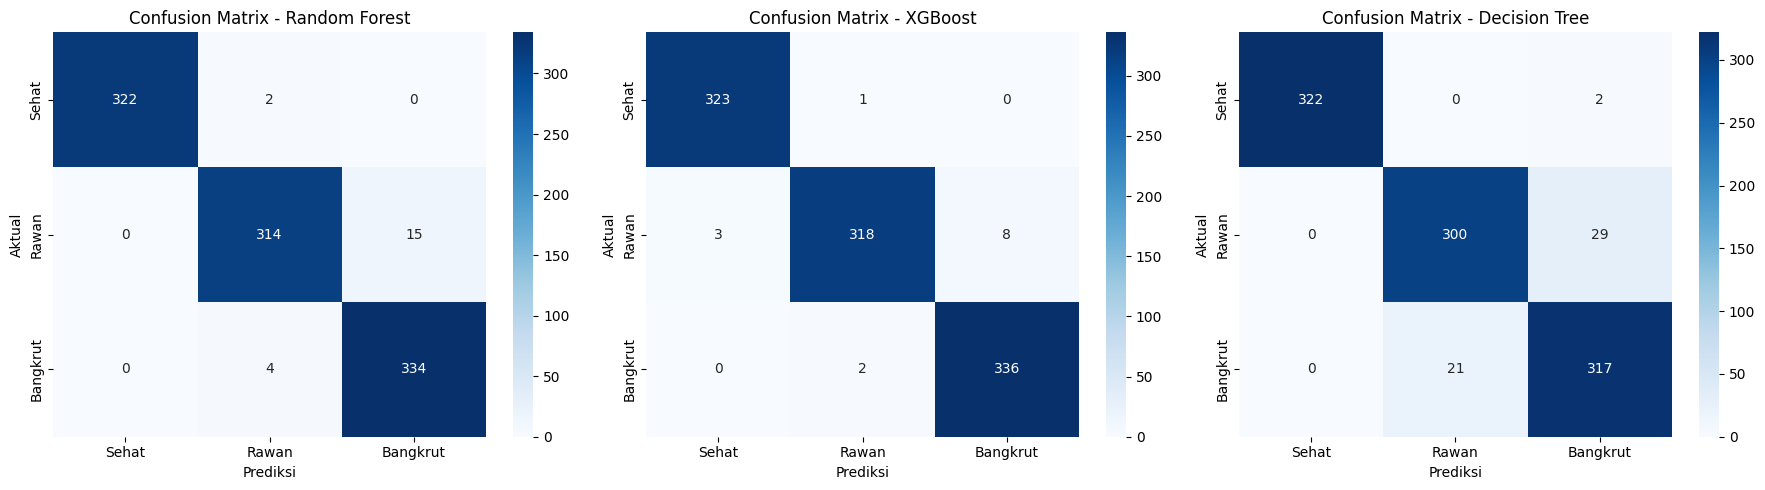

In [ ]:
# Confusion Matrix tiap algoritma
fig, axes = plt.subplots(1, 3, figsize=(18,5))
for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test3)
    cm = confusion_matrix(y_test3, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=['Sehat','Rawan','Bangkrut'],
                yticklabels=['Sehat','Rawan','Bangkrut'])
    ax.set_title(f'Confusion Matrix - {name}')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')
plt.tight_layout()
plt.show()

# model comparison

In [ ]:
# Tabel perbandingan akurasi
results = {
    'Algoritma': ['Random Forest', 'XGBoost', 'Decision Tree'],
    'Default (80:20)': [97.33, 98.44, 94.15],
    'Default (70:30)': [97.54, 98.38, 94.18],
    'Default (90:10)': [97.98, 98.69, 94.65],
    'Setelah Tuning' : [97.88, 98.59, 94.75]
}

df_results = pd.DataFrame(results)
print("\n=== Tabel Perbandingan Akurasi ===")
display(df_results)


=== Tabel Perbandingan Akurasi ===


,Algoritma,Default (80:20),Default (70:30),Default (90:10),Setelah Tuning
0,Random Forest,97.33,97.54,97.98,97.88
1,XGBoost,98.44,98.38,98.69,98.59
2,Decision Tree,94.15,94.18,94.65,94.75


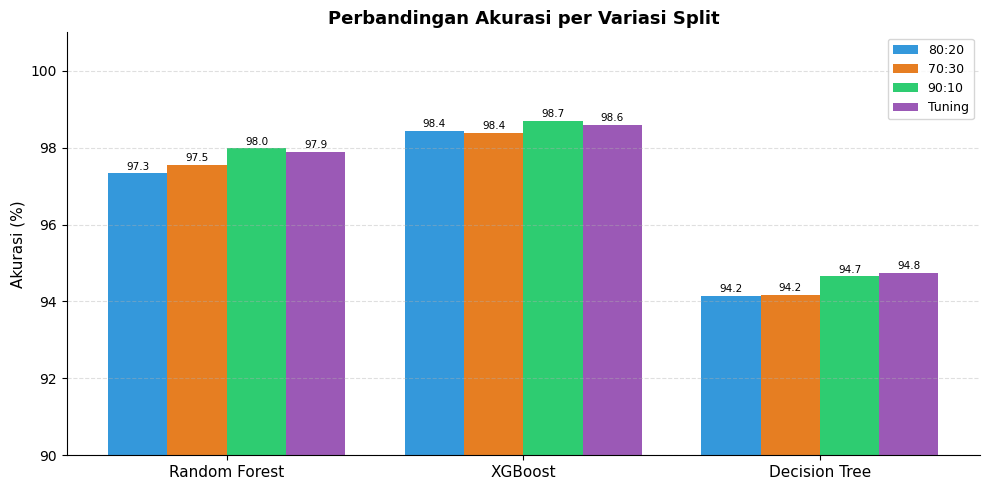

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6']
labels = ['80:20', '70:30', '90:10', 'Tuning']
keys = ['Default (80:20)', 'Default (70:30)', 'Default (90:10)', 'Setelah Tuning']

x = range(len(results['Algoritma']))
width = 0.2

for i, (key, label, color) in enumerate(zip(keys, labels, colors)):
    offset = (i - 1.5) * width
    bars = ax.bar([xi + offset for xi in x], results[key],
                  width=width, label=label, color=color,
                  edgecolor='none')
    # Tambah angka di atas bar
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.05,
                f'{bar.get_height():.1f}',
                ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(list(x))
ax.set_xticklabels(results['Algoritma'], fontsize=11)
ax.set_ylabel('Akurasi (%)', fontsize=11)
ax.set_title('Perbandingan Akurasi per Variasi Split', fontsize=13, fontweight='bold')
ax.set_ylim(90, 101)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

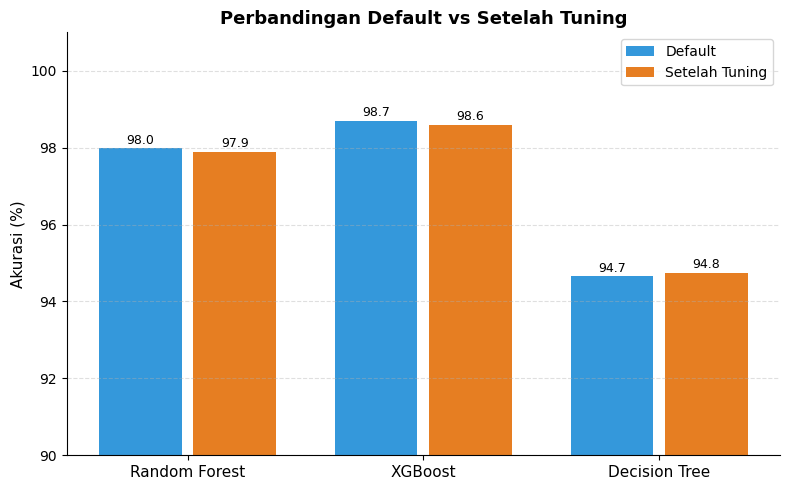

In [ ]:
# Grafik perbandingan default vs tuning
fig, ax = plt.subplots(figsize=(8, 5))

x = range(len(results['Algoritma']))
width = 0.35

bars1 = ax.bar([i - 0.2 for i in x], results['Default (90:10)'],
               width=width, label='Default', color='#3498db', edgecolor='none')
bars2 = ax.bar([i + 0.2 for i in x], results['Setelah Tuning'],
               width=width, label='Setelah Tuning', color='#e67e22', edgecolor='none')

# Angka di atas bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(list(x))
ax.set_xticklabels(results['Algoritma'], fontsize=11)
ax.set_ylabel('Akurasi (%)', fontsize=11)
ax.set_title('Perbandingan Default vs Setelah Tuning', fontsize=13, fontweight='bold')
ax.set_ylim(90, 101)
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# inference

In [ ]:
# Ambil 1 baris data Sehat sebagai template
y_original = df['Risk_Class']
data_for_inference = X[y_original == 0].iloc[[0]].copy()

# Set nilai fitur yang ingin diprediksi
data_for_inference[' ROA(A) before interest and % after tax'] = 0.60
data_for_inference[' ROA(C) before interest and depreciation before interest'] = 0.55
data_for_inference[' ROA(B) before interest and depreciation after tax'] = 0.58

# Tampilkan data inferensi
kolom_tampil = [
    ' ROA(A) before interest and % after tax',
    ' ROA(C) before interest and depreciation before interest',
    ' ROA(B) before interest and depreciation after tax'
]

print("=== Prediksi Risiko Kebangkrutan Perusahaan ===")
print("\nData yang akan diprediksi:")
display(data_for_inference[kolom_tampil].reset_index(drop=True))

# Prediksi
prediksi = random_search_xgb.best_estimator_.predict(data_for_inference)
kelas = {0: 'Sehat', 1: 'Rawan', 2: 'Bangkrut'}
print(f"\nHasil Prediksi: {kelas[prediksi[0]]}")

=== Prediksi Risiko Kebangkrutan Perusahaan ===

Data yang akan diprediksi:


,ROA(A) before interest and % after tax,ROA(C) before interest and depreciation before interest,ROA(B) before interest and depreciation after tax
0,0.6,0.55,0.58



Hasil Prediksi: Sehat
